# Week 3 · Lab — Tabu Search for Graph Colouring and the QAP

**Goals**
- Implement **TabuCol** (Hertz & de Werra, 1987) for graph $k$-colouring with the conflict-based neighbourhood
  and an incrementally maintained $\gamma$ matrix (validated against recomputation).
- Find the smallest $k$ TabuCol can colour on random $G(n,p)$ graphs and bracket it between a greedy clique lower
  bound and the greedy / DSATUR upper bounds; validate TabuCol against an exact chromatic number on small graphs.
- Compare **robust tabu search** with **simulated annealing** (Week 2, re-implemented here) on random QAP
  instances ($n = 25$) at equal evaluation budgets, with a **Wilcoxon signed-rank test** implemented from scratch
  and validated against `scipy.stats.wilcoxon`.
- AI link: tabu search for **feature selection**, validated against exhaustive enumeration.

**Prerequisites:** Notebooks 1–2 (tabu search, robust TS), Week 2 (simulated annealing).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import time
from scipy import stats
from utils import random_qap, qap_cost, PALETTE

## Part A — Graph colouring

A proper $k$-colouring of $G = (V, E)$ is $c: V \to \lbrace 0, \dots, k-1 \rbrace$ with $c(u) \ne c(v)$ for every
edge; the chromatic number $\chi(G)$ is the smallest such $k$. Computing $\chi(G)$ is NP-hard (Karp 1972, who
showed that deciding $\chi(G) \le k$ for $k$ given in the input is NP-complete), and $k$-colourability stays
NP-complete for every *fixed* $k \ge 3$ (Stockmeyer 1973; Garey, Johnson & Stockmeyer 1976). Bounds: $\omega(G) \le \chi(G) \le \Delta(G) + 1$, where $\omega$ is the clique number.

**TabuCol** (Hertz & de Werra 1987) fixes $k$ and minimises the number of **conflicting edges**
$f(c) = \vert \lbrace uv \in E : c(u) = c(v) \rbrace \vert$ over *all* (not necessarily proper) colourings; $f = 0$
means a proper $k$-colouring was found.

- **Neighbourhood (conflict-based):** recolour a vertex $v$ that is in conflict to some other colour, $(v, c')$.
  Only conflicting vertices are considered — a move of a conflict-free vertex cannot reduce $f$.
- **Incremental evaluation:** keep $\gamma_{v c} = \vert \lbrace u \in N(v) : c(u) = c \rbrace \vert$. Then
  $\Delta f(v, c') = \gamma_{v c'} - \gamma_{v c(v)}$ in $O(1)$, and after the move only the rows of the neighbours
  of $v$ change: $\gamma_{u, c(v)} \mathrel{-}= 1$, $\gamma_{u, c'} \mathrel{+}= 1$ for $u \in N(v)$.
- **Tabu attribute:** the pair $(v, c_{old})$ — $v$ may not return to its old colour for $t$ iterations.
  Hertz & de Werra used a fixed tenure of 7 on a sampled neighbourhood; we use the full conflict neighbourhood and
  the dynamic tenure of Galinier & Hao (1999), $t = U\lbrace 0, \dots, 9 \rbrace + \lfloor 0.6 \, \vert C \vert \rfloor$
  with $C$ the set of conflicting vertices: the more conflicts, the longer the memory.
- **Aspiration** by objective; ties between best moves are broken uniformly at random.

```text
TabuCol(G, k):  c <- random colouring ; compute gamma ; f <- conflicts
  while f > 0 and iterations left:
      C <- { v : gamma[v, c(v)] > 0 }
      (v, c') <- argmin over v in C, c' != c(v), admissible, of gamma[v,c'] - gamma[v,c(v)]
      update gamma rows of N(v) ; tabu (v, c(v)) for t iterations ; c(v) <- c'
```

In [2]:
def gnp(n, p, rng):
    A = np.triu(rng.random((n, n)) < p, 1)
    return A | A.T


def conflicts(A, col):
    return int((A & (col[:, None] == col[None, :])).sum() // 2)


def greedy_colouring(A, order):
    col = -np.ones(len(A), dtype=int)
    for v in order:
        used = set(col[A[v] & (col >= 0)].tolist())
        c = 0
        while c in used:
            c += 1
        col[v] = c
    return col


def dsatur(A):
    """Brélaz (1979): colour next the vertex with most distinct neighbour colours (ties: largest degree)."""
    n = len(A); col = -np.ones(n, dtype=int); deg = A.sum(1)
    sat = [set() for _ in range(n)]
    for _ in range(n):
        un = np.flatnonzero(col < 0)
        s = np.array([len(sat[v]) for v in un])
        cand = un[s == s.max()]
        v = cand[np.argmax(deg[cand])]
        c = 0
        while c in sat[v]:
            c += 1
        col[v] = c
        for u in np.flatnonzero(A[v]):
            sat[u].add(c)
    return col


def greedy_clique(A, start):
    """Grow a clique from `start`, always adding the candidate with most neighbours among the candidates."""
    clique = [start]
    cand = np.flatnonzero(A[start])
    while len(cand):
        sub = A[np.ix_(cand, cand)].sum(1)
        v = cand[np.argmax(sub)]
        clique.append(int(v))
        cand = cand[A[v, cand]]
    return clique


def tabucol(A, k, rng, max_iter, nbrs=None, L=10, lam=0.6, validate_every=0):
    n = len(A)
    nbrs = nbrs or [np.flatnonzero(A[v]) for v in range(n)]
    col = rng.integers(k, size=n)
    gamma = (A.astype(np.int64) @ np.eye(k, dtype=np.int64)[col])
    f = int(gamma[np.arange(n), col].sum() // 2)
    best, best_col = f, col.copy()
    tabu = np.zeros((n, k), dtype=np.int64)
    evals, ok = 0, True
    for it in range(1, max_iter + 1):
        if f == 0:
            break
        own = gamma[np.arange(n), col]
        cv = np.flatnonzero(own > 0)
        dl = (gamma[cv] - own[cv][:, None]).astype(float)
        dl[np.arange(len(cv)), col[cv]] = np.inf
        evals += len(cv) * (k - 1)
        adm = (tabu[cv] < it) | (f + dl < best)
        dl = np.where(adm, dl, np.inf)
        m = dl.min()
        if not np.isfinite(m):
            continue
        ii, cc = np.nonzero(dl == m)
        j = int(rng.integers(len(ii)))
        v, c = cv[ii[j]], cc[j]
        old = col[v]
        gamma[nbrs[v], old] -= 1
        gamma[nbrs[v], c] += 1
        col[v] = c
        f += int(m)
        tabu[v, old] = it + int(rng.integers(L)) + int(lam * len(cv))
        if f < best:
            best, best_col = f, col.copy()
        if validate_every and it % validate_every == 0:
            ok &= np.array_equal(gamma, A.astype(np.int64) @ np.eye(k, dtype=np.int64)[col]) and f == conflicts(A, col)
    return dict(col=best_col, f=best, iters=it, evals=evals, gamma_ok=ok)

### Validation

1. The incremental $\gamma$ matrix and conflict count are compared with a full recomputation
   ($\gamma = A \cdot \mathrm{onehot}(c)$, conflicts counted edge by edge) every 10 iterations of a long run.
2. On small graphs, $\chi(G)$ is computed **exactly** by an independent backtracking search (colour vertices in
   decreasing-degree order, a new colour only if it is the next unused one — this breaks the $k!$ colour symmetry);
   TabuCol must find a proper colouring with exactly $\chi(G)$ colours, and none with fewer is possible by definition.
3. Greedy, DSATUR and TabuCol outputs must be proper colourings; greedy cliques must be cliques.

In [3]:
def exact_chromatic(A):
    n = len(A)
    order = np.argsort(-A.sum(1))
    lb = max(len(greedy_clique(A, s)) for s in range(n))
    for k in range(lb, n + 1):
        col = -np.ones(n, dtype=int)

        def bt(i, used):
            if i == n:
                return True
            v = order[i]
            forbidden = set(col[A[v] & (col >= 0)].tolist())
            for c in range(min(used + 1, k)):
                if c not in forbidden:
                    col[v] = c
                    if bt(i + 1, max(used, c + 1)):
                        return True
                    col[v] = -1
            return False

        if bt(0, 0):
            return k, col.copy()


A50 = gnp(60, 0.5, np.random.default_rng(1))
r = tabucol(A50, 9, np.random.default_rng(0), 3000, validate_every=10)
check_true(r["gamma_ok"], "incremental gamma matrix and conflict count equal recomputation along the run")

t0 = time.time()
exact_ok, props = True, True
for g in range(6):
    Ag = gnp(16, 0.45, np.random.default_rng(10 + g))
    chi, colx = exact_chromatic(Ag)
    props &= conflicts(Ag, colx) == 0
    rt = tabucol(Ag, chi, np.random.default_rng(g), 5000)
    exact_ok &= rt["f"] == 0 and conflicts(Ag, rt["col"]) == 0 and rt["col"].max() < chi
    print(f"graph {g}: n=16, |E|={Ag.sum() // 2:3d}, chi = {chi} (exact), TabuCol with k = chi: conflicts {rt['f']}")
check_true(props, "backtracking colourings are proper")
check_true(exact_ok, "TabuCol finds a proper colouring with exactly chi(G) colours on all 6 small graphs")
print(f"({time.time() - t0:.1f} s)")

[PASS] incremental gamma matrix and conflict count equal recomputation along the run
graph 0: n=16, |E|= 60, chi = 5 (exact), TabuCol with k = chi: conflicts 0
graph 1: n=16, |E|= 63, chi = 5 (exact), TabuCol with k = chi: conflicts 0
graph 2: n=16, |E|= 62, chi = 6 (exact), TabuCol with k = chi: conflicts 0
graph 3: n=16, |E|= 48, chi = 5 (exact), TabuCol with k = chi: conflicts 0
graph 4: n=16, |E|= 56, chi = 5 (exact), TabuCol with k = chi: conflicts 0
graph 5: n=16, |E|= 46, chi = 5 (exact), TabuCol with k = chi: conflicts 0
[PASS] backtracking colourings are proper
[PASS] TabuCol finds a proper colouring with exactly chi(G) colours on all 6 small graphs
(0.0 s)


### Minimal $k$ on random graphs

For three random graphs ($G(100, 0.5)$, $G(100, 0.3)$, $G(80, 0.5)$) we compute: the best of 20 random-order greedy
colourings, DSATUR, and the largest of $n$ greedy cliques (a lower bound on $\chi$). TabuCol then starts at
$k = \text{DSATUR} - 1$ and decreases $k$ while it finds a proper colouring within $20\,000$ iterations
(3 seeds per $k$; $k$ counts as solved if any seed succeeds).

In [4]:
t0 = time.time()
graphs = [(100, 0.5), (100, 0.3), (80, 0.5)]
summary = []
traces = {}
for gi, (n, p) in enumerate(graphs):
    A = gnp(n, p, np.random.default_rng(100 + gi))
    nbrs = [np.flatnonzero(A[v]) for v in range(n)]
    g_rng = np.random.default_rng(gi)
    greedy_cols = [greedy_colouring(A, g_rng.permutation(n)) for _ in range(20)]
    assert all(conflicts(A, c) == 0 for c in greedy_cols)
    k_greedy = min(c.max() + 1 for c in greedy_cols)
    cd = dsatur(A); assert conflicts(A, cd) == 0
    k_ds = cd.max() + 1
    cliques = [greedy_clique(A, s) for s in range(n)]
    assert all(A[np.ix_(c, c)].sum() == len(c) * (len(c) - 1) for c in cliques)
    omega_lb = max(len(c) for c in cliques)
    k, k_best, iters = k_ds - 1, k_ds, {}
    while k >= omega_lb:
        runs = [tabucol(A, k, np.random.default_rng(1000 * gi + s), 20_000, nbrs) for s in range(3)]
        good = [r_ for r_ in runs if r_["f"] == 0]
        iters[k] = [r_["iters"] if r_["f"] == 0 else np.nan for r_ in runs]
        if not good:
            break
        assert all(conflicts(A, r_["col"]) == 0 and r_["col"].max() < k for r_ in good)
        k_best, k = k, k - 1
    traces[gi] = iters
    summary.append((n, p, omega_lb, k_best, k_ds, k_greedy))
    print(f"G({n},{p}): clique LB {omega_lb:2d} <= chi <= TabuCol {k_best:2d} <= DSATUR {k_ds:2d} <= greedy(best of 20) {k_greedy:2d}")
print(f"({time.time() - t0:.1f} s)")
check_true(all(s[3] < s[4] for s in summary), "TabuCol improves on DSATUR on every graph")

G(100,0.5): clique LB  9 <= chi <= TabuCol 14 <= DSATUR 17 <= greedy(best of 20) 20


G(100,0.3): clique LB  6 <= chi <= TabuCol 10 <= DSATUR 11 <= greedy(best of 20) 13


G(80,0.5): clique LB  8 <= chi <= TabuCol 13 <= DSATUR 16 <= greedy(best of 20) 17
(50.0 s)
[PASS] TabuCol improves on DSATUR on every graph


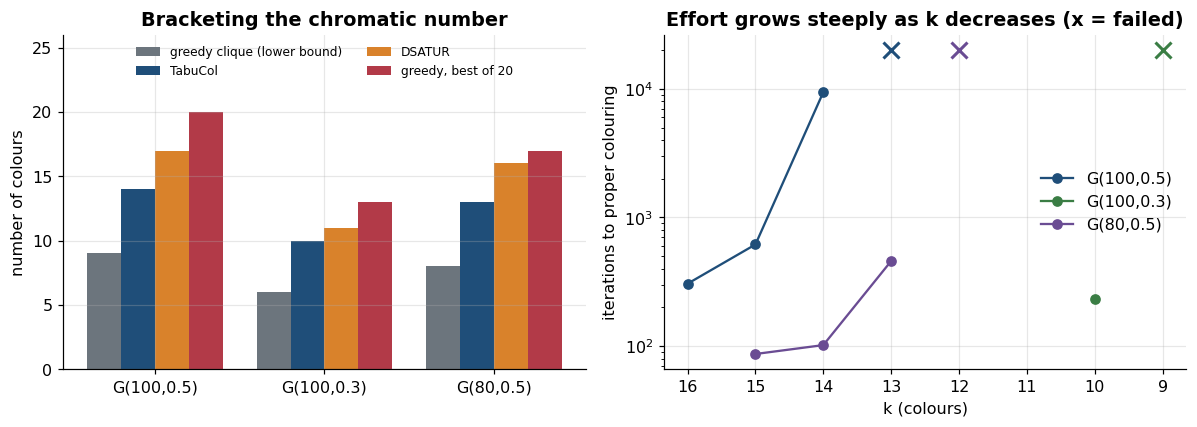

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
labels = [f"G({n},{p})" for n, p, *_ in summary]
xx = np.arange(len(summary)); wd = 0.2
for o, (idx, name, c) in enumerate([(2, "greedy clique (lower bound)", PALETTE["grey"]), (3, "TabuCol", PALETTE["blue"]),
                                    (4, "DSATUR", PALETTE["orange"]), (5, "greedy, best of 20", PALETTE["red"])]):
    ax.bar(xx + (o - 1.5) * wd, [s[idx] for s in summary], wd, label=name, color=c)
ax.set_xticks(xx, labels); ax.set_ylabel("number of colours"); ax.set_title("Bracketing the chromatic number")
ax.set_ylim(0, 26); ax.legend(fontsize=8, ncol=2, loc="upper center")
ax = axes[1]
for gi, c in zip(traces, [PALETTE["blue"], PALETTE["green"], PALETTE["purple"]]):
    ks = sorted(traces[gi])
    med = [np.nanmedian(traces[gi][k]) if np.any(np.isfinite(traces[gi][k])) else np.nan for k in ks]
    ax.plot(ks, med, "o-", color=c, label=labels[gi])
    failed = [k for k in ks if not np.any(np.isfinite(traces[gi][k]))]
    ax.plot(failed, [20_000] * len(failed), "x", color=c, ms=10, mew=2)
ax.set_yscale("log"); ax.set_xlabel("k (colours)"); ax.set_ylabel("iterations to proper colouring")
ax.set_title("Effort grows steeply as k decreases (x = failed)"); ax.invert_xaxis(); ax.legend()
fig.tight_layout()
savefig("w3_tabucol.png"); plt.show()

## Part B — Robust tabu search vs simulated annealing on the QAP

**Robust TS** (Notebook 2): weak ("both") tabu rule, tenure uniform in $[0.9n, 1.1n]$ re-drawn every
$2 \lceil 1.1n \rceil$ iterations, aspiration by objective (the long-term aspiration is omitted: with this budget
a run lasts only about $n^2/2$ iterations, far fewer than a typical $t_{asp}$ of several $n^2$), Taillard's
$O(n^2)$ incremental delta matrix; one iteration examines
$n(n-1)/2$ swaps = $n(n-1)/2$ evaluations.

**SA** (Week 2): random swap, $O(n)$ delta, Metropolis acceptance, geometric cooling
$T_{k+1} = \rho T_k$ from $T_0$ to $T_f = 10^{-3} T_0$ over the budget, where $T_0 = \bar\delta^{+} / \ln 2$ makes an
average uphill move (estimated from 200 random swaps, which are charged to the budget) accepted with probability
$1/2$ at the start. One step = one evaluation.

Both get the same budget of $10^5$ evaluations on 12 random instances with $n = 25$ (one paired run per instance,
same seed).

In [6]:
def qap_delta(p, r, s, F, D):
    dF = F[:, r] - F[:, s]
    dD = D[p, p[s]] - D[p, p[r]]
    return 2.0 * (dF @ dD + 2.0 * F[r, s] * D[p[r], p[s]])


def qap_delta_matrix(p, F, D):
    Dp = D[np.ix_(p, p)]
    M = F @ Dp
    dg = np.diag(M)
    Delta = 2.0 * (M + M.T - dg[:, None] - dg[None, :] + 2.0 * F * Dp)
    np.fill_diagonal(Delta, 0.0)
    return Delta


def qap_update_after_swap(Delta, q, r, s, F, D):
    a = F[r] - F[s]
    b = D[q[s], q] - D[q[r], q]
    new = Delta + 2.0 * np.subtract.outer(a, a) * np.subtract.outer(b, b)
    Dq = D[np.ix_(q, q)]
    diagM = np.sum(F * Dq, axis=0)
    for i in (r, s):
        row = 2.0 * (F[:, i] @ Dq + Dq[:, i] @ F - diagM[i] - diagM + 2.0 * F[i] * Dq[i])
        new[i, :] = row; new[:, i] = row
    np.fill_diagonal(new, 0.0)
    return new


def robust_ts(F, D, max_evals, rng):
    n = len(F)
    p = rng.permutation(n); cost = qap_cost(p, F, D)
    best, best_p = cost, p.copy()
    Delta = qap_delta_matrix(p, F, D)
    iu, ju = np.triu_indices(n, 1)
    tabu_until = np.full((n, n), -1, dtype=np.int64)
    t_lo, t_hi = int(np.floor(0.9 * n)), int(np.ceil(1.1 * n))
    evals, k, t = 0, 0, t_hi
    ev_tr, bs_tr = [], []
    while evals + len(iu) <= max_evals:
        k += 1; evals += len(iu)
        if (k - 1) % (2 * t_hi) == 0:
            t = int(rng.integers(t_lo, t_hi + 1))
        d = Delta[iu, ju]
        tabu = (tabu_until[iu, p[ju]] >= k) & (tabu_until[ju, p[iu]] >= k)
        adm = ~tabu | (cost + d < best - 1e-9)
        if not adm.any():
            adm[:] = True
        j = int(np.argmin(np.where(adm, d, np.inf)))
        r, s = int(iu[j]), int(ju[j])
        tabu_until[r, p[r]] = k + t; tabu_until[s, p[s]] = k + t
        cost += d[j]
        q = p.copy(); q[[r, s]] = q[[s, r]]
        Delta = qap_update_after_swap(Delta, q, r, s, F, D); p = q
        if cost < best - 1e-9:
            best, best_p = cost, p.copy()
        ev_tr.append(evals); bs_tr.append(best)
    return dict(best=float(best), perm=best_p, evals=evals, ev=np.array(ev_tr), bs=np.array(bs_tr))


def simulated_annealing(F, D, max_evals, rng, n_probe=200, final_ratio=1e-3):
    n = len(F)
    p = rng.permutation(n); cost = qap_cost(p, F, D)
    probe = [qap_delta(p, *rng.choice(n, 2, replace=False), F, D) for _ in range(n_probe)]
    up = np.array([d for d in probe if d > 0])
    T = up.mean() / np.log(2.0)
    steps = max_evals - n_probe
    rho = final_ratio ** (1.0 / steps)
    best, best_p = cost, p.copy()
    R = rng.integers(0, n, size=(steps, 2)); U = rng.random(steps)
    ev_tr, bs_tr = [], []
    for i in range(steps):
        r, s = R[i]
        if r != s:
            d = qap_delta(p, r, s, F, D)
            if d <= 0 or U[i] < np.exp(-d / T):
                p[r], p[s] = p[s], p[r]
                cost += d
                if cost < best - 1e-9:
                    best, best_p = cost, p.copy()
        T *= rho
        if (i + 1) % 1000 == 0:
            ev_tr.append(n_probe + i + 1); bs_tr.append(best)
    return dict(best=float(best), perm=best_p, evals=max_evals, ev=np.array(ev_tr), bs=np.array(bs_tr))

In [7]:
Fx, Dx = random_qap(12, np.random.default_rng(3))
rt, rs = robust_ts(Fx, Dx, 20_000, np.random.default_rng(0)), simulated_annealing(Fx, Dx, 20_000, np.random.default_rng(0))
check_close(rt["best"], qap_cost(rt["perm"], Fx, Dx), "robust TS: reported best = qap_cost(perm)")
check_close(rs["best"], qap_cost(rs["perm"], Fx, Dx), "SA: reported best = qap_cost(perm)")
check_true(rt["evals"] <= 20_000 and rs["evals"] <= 20_000, "both runs within the 20,000-evaluation budget")

[PASS] robust TS: reported best = qap_cost(perm): got 2466.82, expected 2466.82
[PASS] SA: reported best = qap_cost(perm): got 2475.22, expected 2475.22
[PASS] both runs within the 20,000-evaluation budget


### Wilcoxon signed-rank test from scratch

For paired observations $(x_i, y_i)$, let $d_i = x_i - y_i$, discard $d_i = 0$ (Wilcoxon's convention), rank
$\vert d_i \vert$ with average ranks for ties, and let $W^{+}$ ($W^{-}$) be the sum of ranks of positive (negative)
differences; the reported statistic is $\min(W^{+}, W^{-})$. Under $H_0$ (differences symmetric about 0) each rank
is positive with probability $1/2$ independently, so with $m$ non-zero differences and no ties

$$
P(W^{+} = w) = \frac{c_m(w)}{2^m}, \qquad c_j(w) = c_{j-1}(w) + c_{j-1}(w - j),
$$

where $c_m(w)$ counts subsets of $\lbrace 1, \dots, m \rbrace$ with sum $w$ (dynamic programme). The two-sided exact
$p$-value is $\min(1, 2 \min(P(W^{+} \le w^{+}), P(W^{+} \ge w^{+})))$. With ties (or large $m$) we use the normal
approximation with mean $m(m+1)/4$ and variance $m(m+1)(2m+1)/24 - \sum_g (t_g^3 - t_g)/48$ over tie groups $g$.

In [8]:
def average_ranks(a):
    order = np.argsort(a, kind="mergesort")
    ranks = np.empty(len(a))
    sa = a[order]
    i = 0
    while i < len(a):
        j = i
        while j + 1 < len(a) and sa[j + 1] == sa[i]:
            j += 1
        ranks[order[i:j + 1]] = 0.5 * (i + j) + 1.0
        i = j + 1
    return ranks


def wilcoxon_signed_rank(x, y, method="auto"):
    d = np.asarray(x, float) - np.asarray(y, float)
    d = d[d != 0]
    m = len(d)
    r = average_ranks(np.abs(d))
    w_plus, w_minus = r[d > 0].sum(), r[d < 0].sum()
    ties = len(np.unique(np.abs(d))) < m
    if method == "auto":
        method = "exact" if (m <= 50 and not ties) else "approx"
    if method == "exact":
        c = np.zeros(m * (m + 1) // 2 + 1); c[0] = 1.0
        for j in range(1, m + 1):
            c[j:] = c[j:] + c[:-j].copy()
        pmf = c / 2.0 ** m
        wp = int(round(w_plus))
        p = min(1.0, 2 * min(pmf[:wp + 1].sum(), pmf[wp:].sum()))
    else:
        _, t = np.unique(np.abs(d), return_counts=True)
        var = m * (m + 1) * (2 * m + 1) / 24 - np.sum(t**3 - t) / 48
        z = (w_plus - m * (m + 1) / 4) / np.sqrt(var)
        p = 2 * stats.norm.sf(abs(z))
    return min(w_plus, w_minus), p, w_plus, m

Validation against `scipy.stats.wilcoxon` (an independent implementation): exact method on 20 random paired
samples without ties, and the normal approximation (no continuity correction) on 20 samples with heavy ties and
zeros.

In [9]:
vr = np.random.default_rng(42)
err_s, err_p = 0.0, 0.0
for _ in range(20):
    m = int(vr.integers(6, 25))
    x, y = vr.normal(size=m), vr.normal(0.3, 1, size=m)
    W, p, *_ = wilcoxon_signed_rank(x, y, "exact")
    ref = stats.wilcoxon(x, y, method="exact")
    err_s, err_p = max(err_s, abs(W - ref.statistic)), max(err_p, abs(p - ref.pvalue))
check_close(err_s, 0.0, "exact method: statistic vs scipy (max abs error over 20 samples)")
check_close(err_p, 0.0, "exact method: p-value vs scipy (max abs error over 20 samples)", atol=1e-10)
err_s, err_p = 0.0, 0.0
for _ in range(20):
    m = int(vr.integers(15, 60))
    x, y = vr.integers(0, 6, size=m).astype(float), vr.integers(0, 6, size=m).astype(float)
    W, p, *_ = wilcoxon_signed_rank(x, y, "approx")
    ref = stats.wilcoxon(x, y, method="approx", correction=False, zero_method="wilcox")
    err_s, err_p = max(err_s, abs(W - ref.statistic)), max(err_p, abs(p - ref.pvalue))
check_close(err_s, 0.0, "normal approximation with ties/zeros: statistic vs scipy")
check_close(err_p, 0.0, "normal approximation with ties/zeros: p-value vs scipy", atol=1e-10)

[PASS] exact method: statistic vs scipy (max abs error over 20 samples): got 0.0, expected 0.0
[PASS] exact method: p-value vs scipy (max abs error over 20 samples): got 0.0, expected 0.0
[PASS] normal approximation with ties/zeros: statistic vs scipy: got 0.0, expected 0.0
[PASS] normal approximation with ties/zeros: p-value vs scipy: got 0.0, expected 0.0


### The equal-budget experiment

In [10]:
t0 = time.time()
n_q, budget_q, n_inst = 25, 100_000, 12
ts_res, sa_res = [], []
for i in range(n_inst):
    Fi, Di = random_qap(n_q, np.random.default_rng(700 + i))
    ts_res.append(robust_ts(Fi, Di, budget_q, np.random.default_rng(i)))
    sa_res.append(simulated_annealing(Fi, Di, budget_q, np.random.default_rng(i)))
ts_b = np.array([r_["best"] for r_ in ts_res]); sa_b = np.array([r_["best"] for r_ in sa_res])
W, pval, w_plus, m = wilcoxon_signed_rank(ts_b, sa_b)
rel = 100 * (ts_b - sa_b) / sa_b
print(f"robust TS better on {np.sum(ts_b < sa_b)}/{n_inst} instances, SA better on {np.sum(sa_b < ts_b)}")
print(f"median relative difference (TS - SA)/SA = {np.median(rel):.2f}%  IQR [{np.percentile(rel, 25):.2f}, {np.percentile(rel, 75):.2f}]")
print(f"Wilcoxon signed-rank: W = {W:.0f} (W+ = {w_plus:.0f}, m = {m}), two-sided p = {pval:.4f}")
ref = stats.wilcoxon(ts_b, sa_b)
check_close(pval, ref.pvalue, "own Wilcoxon p-value on the experiment = scipy", atol=1e-10)
print(f"({time.time() - t0:.1f} s)")

robust TS better on 4/12 instances, SA better on 8
median relative difference (TS - SA)/SA = 0.04%  IQR [-0.10, 0.26]
Wilcoxon signed-rank: W = 29 (W+ = 49, m = 12), two-sided p = 0.4697
[PASS] own Wilcoxon p-value on the experiment = scipy: got 0.469727, expected 0.469727
(44.9 s)


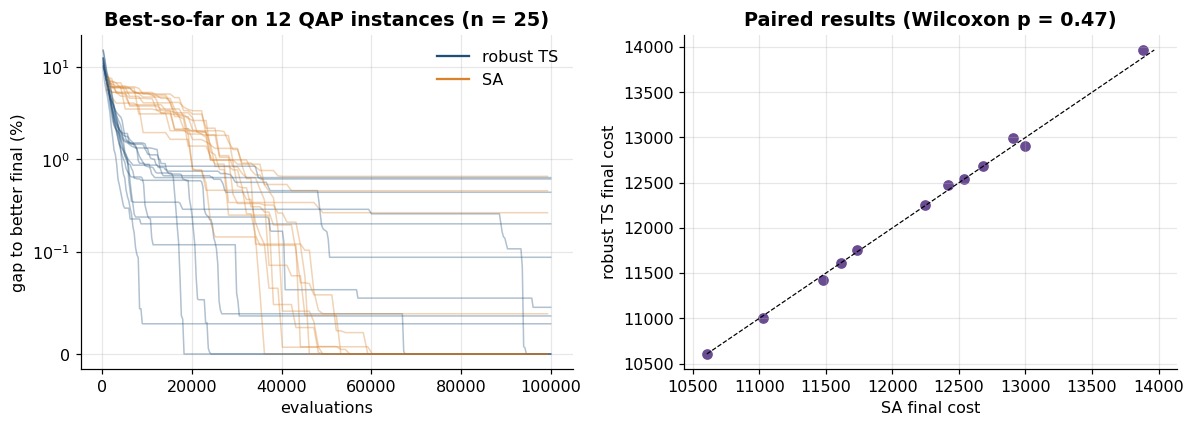

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
for r_t, r_s in zip(ts_res, sa_res):
    ref_v = min(r_t["best"], r_s["best"])
    ax.plot(r_t["ev"], 100 * (r_t["bs"] / ref_v - 1), color=PALETTE["blue"], alpha=0.35, lw=1)
    ax.plot(r_s["ev"], 100 * (r_s["bs"] / ref_v - 1), color=PALETTE["orange"], alpha=0.35, lw=1)
ax.plot([], [], color=PALETTE["blue"], label="robust TS"); ax.plot([], [], color=PALETTE["orange"], label="SA")
ax.set_yscale("symlog", linthresh=0.1); ax.set_xlabel("evaluations"); ax.set_ylabel("gap to better final (%)")
ax.set_title("Best-so-far on 12 QAP instances (n = 25)"); ax.legend()
ax = axes[1]
ax.scatter(sa_b, ts_b, color=PALETTE["purple"])
lo, hi = min(sa_b.min(), ts_b.min()), max(sa_b.max(), ts_b.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
ax.set_xlabel("SA final cost"); ax.set_ylabel("robust TS final cost")
ax.set_title(f"Paired results (Wilcoxon p = {pval:.3g})")
fig.tight_layout()
savefig("w3_rots_vs_sa.png"); plt.show()

**Interpretation.** The comparison is paired (same instance, same budget), so the signed-rank test is the right
tool; the printed $p$-value and win counts are the result. Here they say that at $10^5$ evaluations on random
$n = 25$ instances **neither method is detectably better**: the wins are split and the median relative difference
is a few hundredths of a percent, with $p$ far above any usual significance level. "No significant difference" is
not "equivalent" — 12 instances only rule out large effects. Two caveats keep the conclusion honest: SA's
performance depends on its cooling schedule (we used one reasonable, budget-aware schedule), and 12 instances
of one random class say nothing about structured QAPLIB instances, where the relative ranking of TS and SA is
known to depend on the instance type (Taillard 1995).

## Part C — AI link: tabu search for feature selection

Feature selection is a 0/1 search problem: choose $S \subseteq \lbrace 1, \dots, d \rbrace$ minimising a validation
loss plus a sparsity penalty,

$$
J(S) = \mathrm{MSE}_{\text{val}}\big(\hat\beta_S\big) + \lambda \vert S \vert, \qquad
\hat\beta_S = \arg\min_\beta \Vert y_{\text{tr}} - X_{\text{tr},S} \beta \Vert^2 .
$$

Greedy *forward selection* adds the single best feature while $J$ decreases — it is a best-improvement local
search restricted to "add" moves: it cannot remove features and stops at the first local optimum it reaches.
Because forward selection stops after a few dozen fits, we also run **random search** (uniformly random subsets)
with exactly the tabu search's number of fits, so that the benefit of the memory-guided search is not just a
benefit of a larger budget. A **suppressor pair** defeats it: two
highly correlated features $x_a \approx x_b$ whose *difference* carries signal are individually useless, so neither
is ever added. Tabu search with bit-flip moves and aspiration can climb through the uphill step of adding one of
them. The tenure is drawn uniformly from $\lbrace 3, \dots, 10 \rbrace$ at every move: with a *fixed* short tenure
the search can lock into a cycle "add $x_a$, drop $x_a$" (the pathology of Notebook 1), and randomising the
tenure, as in robust TS, breaks it. With $d = 14$, exhaustive enumeration of all $2^{14} = 16\,384$ subsets gives the exact optimum.

In [12]:
def make_data(rng, n=300, d=14):
    Z = rng.normal(size=(n, d))
    Z[:, 1] = Z[:, 0] + 0.15 * rng.normal(size=n)            # x0, x1 highly correlated (suppressor pair)
    y = 3.0 * (Z[:, 0] - Z[:, 1]) + 1.0 * Z[:, 2] + 0.6 * Z[:, 3] + 0.5 * rng.normal(size=n)
    return Z[:150], y[:150], Z[150:], y[150:]


def J(S, data, lam=0.02):
    Xtr, ytr, Xva, yva = data
    idx = np.flatnonzero(S)
    Xt = np.column_stack([np.ones(len(ytr)), Xtr[:, idx]])
    Xv = np.column_stack([np.ones(len(yva)), Xva[:, idx]])
    beta = np.linalg.lstsq(Xt, ytr, rcond=None)[0]
    return float(np.mean((yva - Xv @ beta) ** 2) + lam * len(idx))


def forward_selection(data, d):
    S = np.zeros(d, bool); cur = J(S, data); evals = 1
    while True:
        cands = [(J(np.where(np.arange(d) == j, True, S), data), j) for j in np.flatnonzero(~S)]
        evals += len(cands)
        if not cands or min(cands)[0] >= cur:
            return S, cur, evals
        cur, j = min(cands); S[j] = True


def tabu_feature_selection(data, d, rng, iters=60, tenure=(3, 10)):
    S = rng.random(d) < 0.3
    cur = J(S, data); best, best_S, evals = cur, S.copy(), 1
    tabu_until = np.zeros(d, dtype=int)
    for k in range(1, iters + 1):
        vals = np.array([J(np.where(np.arange(d) == j, ~S, S), data) for j in range(d)])
        evals += d
        adm = (tabu_until < k) | (vals < best - 1e-12)
        j = int(np.argmin(np.where(adm, vals, np.inf)))
        S[j] = ~S[j]; cur = vals[j]; tabu_until[j] = k + int(rng.integers(tenure[0], tenure[1] + 1))
        if cur < best - 1e-12:
            best, best_S = cur, S.copy()
    return best_S, best, evals

In [13]:
t0 = time.time()
fs_hits, fwd_hits, rs_hits, fs_evals, fwd_evals, rs_gaps, n_rep = 0, 0, 0, [], [], [], 4
for rep in range(n_rep):
    data = make_data(np.random.default_rng(900 + rep))
    d = data[0].shape[1]
    masks = ((np.arange(2**d)[:, None] >> np.arange(d)) & 1).astype(bool)
    allJ = np.array([J(S, data) for S in masks])
    opt = allJ.min(); S_opt = masks[np.argmin(allJ)]
    S_f, J_f, e_f = forward_selection(data, d)
    fwd_hits += abs(J_f - opt) < 1e-12; fwd_evals.append(e_f)
    for sd in range(4):
        S_t, J_t, e_t = tabu_feature_selection(data, d, np.random.default_rng(sd))
        fs_hits += abs(J_t - opt) < 1e-12; fs_evals.append(e_t)
        # random search with the same number of model fits
        idx_rs = np.random.default_rng(50 + sd).integers(0, 2**d, size=e_t)
        J_rs = allJ[idx_rs].min()                        # allJ[i] = J(masks[i]), computed above
        rs_hits += abs(J_rs - opt) < 1e-12; rs_gaps.append(J_rs - opt)
    if rep == 0:
        print(f"dataset 0: optimal subset {np.flatnonzero(S_opt).tolist()}  J* = {opt:.4f};  "
              f"forward selection picks {np.flatnonzero(S_f).tolist()}  J = {J_f:.4f}")
print(f"exhaustive: {2**d} evaluations per dataset")
print(f"tabu search: exact optimum in {fs_hits}/{4 * n_rep} runs using {int(np.mean(fs_evals))} evaluations each")
print(f"forward selection: exact optimum in {fwd_hits}/{n_rep} datasets using {np.mean(fwd_evals):.0f} evaluations on average")
print(f"random search at the tabu budget: exact optimum in {rs_hits}/{4 * n_rep} runs, "
      f"median excess J - J* = {np.median(rs_gaps):.4f}")
print(f"({time.time() - t0:.1f} s)")
check_true(fs_hits == 4 * n_rep, "tabu search matches the exhaustive optimum on every dataset and seed")
check_true(fwd_hits < n_rep, "forward selection misses the optimum on at least one dataset (suppressor pair)")
check_true(fs_hits > rs_hits, "at equal numbers of model fits tabu search finds the optimum more often than random search")

dataset 0: optimal subset [0, 1, 2, 3]  J* = 0.3517;  forward selection picks [2, 3]  J = 0.4581


exhaustive: 16384 evaluations per dataset
tabu search: exact optimum in 16/16 runs using 841 evaluations each
forward selection: exact optimum in 0/4 datasets using 40 evaluations on average
random search at the tabu budget: exact optimum in 0/16 runs, median excess J - J* = 0.0447
(34.1 s)
[PASS] tabu search matches the exhaustive optimum on every dataset and seed
[PASS] forward selection misses the optimum on at least one dataset (suppressor pair)
[PASS] at equal numbers of model fits tabu search finds the optimum more often than random search


The same pattern — cheap local moves, a short recency memory, aspiration — is how tabu search is used for
wrapper feature selection, channel pruning, and discrete hyperparameter or architecture search when each
evaluation is a model fit: memory lets the search accept the temporary loss that interacting features or
architectural choices require, which a greedy add-one-at-a-time procedure never does.

## Key takeaways

- TabuCol turns an NP-complete decision problem into minimisation of conflicts for fixed $k$; the conflict-based
  neighbourhood, the $O(1)$ delta via the $\gamma$ matrix and its $O(\deg v)$ update are what make it fast. The
  incremental $\gamma$ was validated against recomputation and TabuCol reached the exact $\chi$ on small graphs.
- On random graphs, TabuCol improves on DSATUR and greedy colouring, and the effort needed grows steeply as $k$
  decreases towards the smallest $k$ it can colour; the greedy clique lower bound is weak on dense random graphs, so the gap between bounds is
  mostly a gap in the *lower* bound.
- Algorithm comparisons must be paired, at equal budgets, and tested: our own Wilcoxon signed-rank test (exact
  and normal approximation) matches `scipy.stats.wilcoxon`, and the robust-TS vs SA verdict is read from it, not
  from a single run.
- For feature selection, tabu search escapes the suppressor-pair trap that defeats greedy forward selection, and
  matched the exhaustive optimum at about 5% of its evaluations — more reliably than random search given the
  same number of model fits.

## Exercises

1. ★ Prove that in TabuCol a move of a vertex that is *not* in conflict can never decrease $f$, which justifies
   restricting the neighbourhood to conflicting vertices.
2. ★ Show that DSATUR is exact on bipartite graphs (Brélaz 1979), and construct a small graph on which the
   first-fit greedy colouring with a bad vertex order uses $\Theta(n)$ colours although $\chi = 2$.
3. ★★ Implement the *partial legal* formulation of colouring (Morgenstern; Blöchliger & Zufferey 2008): keep the
   colouring proper and minimise the number of uncoloured vertices. Compare with TabuCol on the three graphs.
4. ★★ Prove that under $H_0$ the Wilcoxon statistic $W^{+}$ (no ties) has mean $m(m+1)/4$ and variance
   $m(m+1)(2m+1)/24$, and derive the tie correction.
5. ★★ Re-run the TS vs SA experiment with five SA schedules (different $T_0$, $T_f$) and apply a Holm correction
   for the five tests. How robust is the verdict to SA tuning?
6. ★★★ Extend Part C to $d = 60$ features with several suppressor pairs, where enumeration is impossible. Compare
   tabu search, forward selection, forward–backward stepwise selection and the lasso path at equal numbers of model
   fits, using repeated cross-validation to avoid overfitting the validation set.